In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
raw_data=[5,7,8,8,12,None,"8 "]

In [63]:
s=pd.Series(raw_data)
s=pd.DataFrame(pd.to_numeric(s.astype(str).str.strip(),errors='coerce'))
s

,0
0,5.0
1,7.0
2,8.0
3,8.0
4,12.0
5,NaN
6,8.0


In [64]:
s.fillna(s.median(),inplace=True)
s

,0
0,5.0
1,7.0
2,8.0
3,8.0
4,12.0
5,8.0
6,8.0


7.5
8.0
0.5
6.75
8.75
      0
0   5.0
4  12.0


<Axes: >

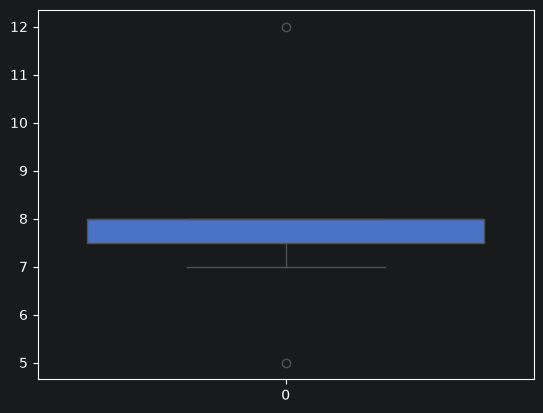

In [66]:
Q1=np.percentile(s,25)
Q3=np.percentile(s,75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outlier=s[(s<lower)|(s>upper)].dropna()
print(Q1)
print(Q3)
print(IQR)
print(lower)
print(upper)
print(outlier)
sb.boxplot(s)

In [68]:
df=pd.DataFrame({
    'score':[80,75,90,60],
    'hours_studied':[4,5,0,3]})
df["efficiency_score"]=np.where(df["hours_studied"]==0,0,df['score']/df['hours_studied'])
print(df)

   score  hours_studied  efficiency_score
0     80              4              20.0
1     75              5              15.0
2     90              0               0.0
3     60              3              20.0


In [80]:
print(s)
print("mean: ",np.mean(s))
print("median: ",np.median(s))
print("mode: ",s.mode())
s.describe()

      0
0   5.0
1   7.0
2   8.0
3   8.0
4  12.0
5   8.0
6   8.0
mean:  8.0
median:  8.0
mode:       0
0  8.0


,0
count,7.000000
mean,8.000000
std,2.081666
min,5.000000
25%,7.500000
50%,8.000000
75%,8.000000
max,12.000000


In [83]:
print(np.std(s))
print(np.var(s))

1.927248223318863
3.7142857142857144


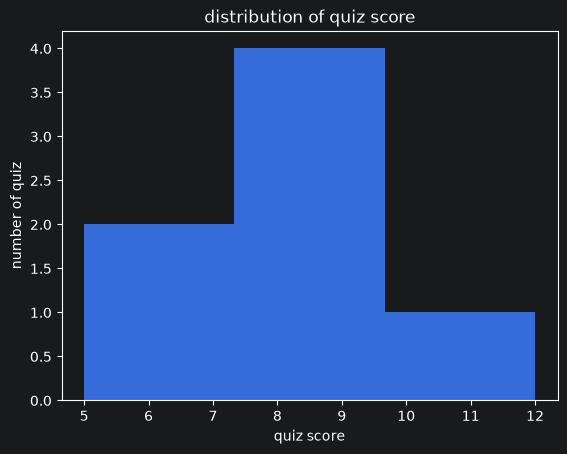

In [85]:
plt.hist(s,bins=3)
plt.title("distribution of quiz score")
plt.xlabel("quiz score")
plt.ylabel("number of quiz")
plt.show()

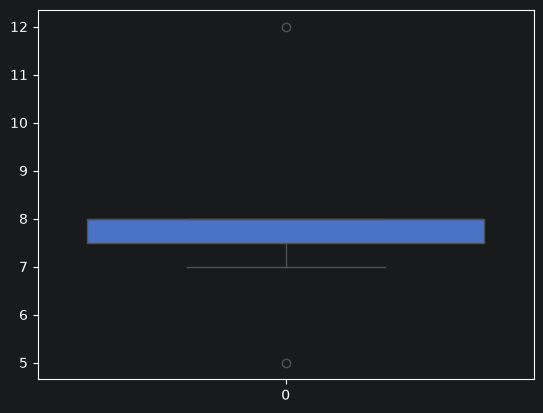

In [86]:
sb.boxplot(s)
plt.show()

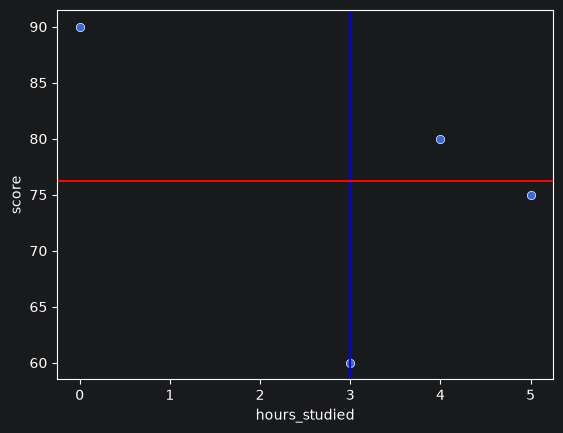

In [92]:
df=pd.DataFrame({
    'score':[80,75,90,60],
    'hours_studied':[4,5,0,3]})
mean_hours=np.mean(df['hours_studied'])
mean_score=np.mean(df['score'])
sb.scatterplot(data=df,x="hours_studied",y="score")
plt.axvline(mean_hours,color='b')
plt.axhline(mean_score,color='r')

                  score  hours_studied
score          1.000000      -0.234686
hours_studied -0.234686       1.000000


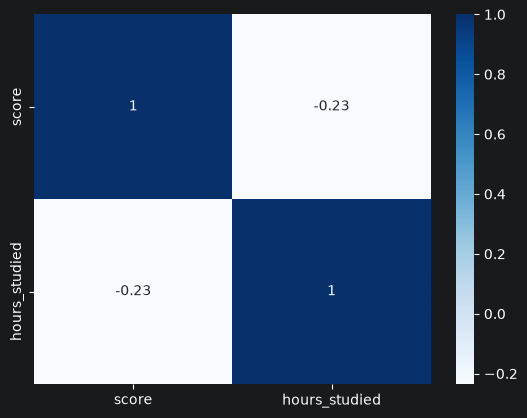

In [93]:
df=pd.DataFrame({
    'score':[80,85,90,60],
    'hours_studied':[4,5,0,3]})
correlation=df.corr(numeric_only=True)
print(correlation)
sb.heatmap(correlation,annot=True,cmap='Blues')
plt.show()


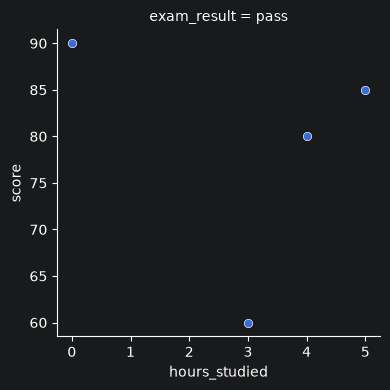

In [97]:
df=pd.DataFrame({
    'score':[80,85,90,60],
    'hours_studied':[4,5,0,3],
    'exam_result':['pass','pass','pass','pass']})
g=sb.FacetGrid(data=df,col='exam_result',height=4)
g.map_dataframe(sb.scatterplot,x="hours_studied",y="score")
g.set_axis_labels("hours_studied","score")
plt.show()